<h1>Bases de Datos para el Big Data</h1>

<h2>02 - Agregación en MongoDB con PyMongo</h2>
<br>
<i>Autor: Marlon Cárdenas Bonett, PhD.</i>
<br>
<i>Año: 2026</i>

### Manipulando datos con pymongo y MongoDB


En este taller, utilizarás un conjunto de datos público para trabajar con MongoDB mediante pymongo.

El conjunto de datos pertenece a una colección pública propiedad de __Airbnb__, la cual hace parte de su apuesta _Open Data_.
En el siguiente enlace podrás obtener más información de la misma:

> * <i class="fa fa-link" style="color:#113D68"></i> [Inside Airbnb](http://insideairbnb.com)

__Contenido de los datos__: información de los anuncios disponibles en la web de Airbnb publicados en algunas ciudades donde opera dicha compañía.

<a id="section1"></a>
### 1. Caso de estudio

En este taller utilizarás datos de __Airbnb__ (en formato JSON o CSV) para manipularlos mediante pymongo, una vez estén almacenados en MongoDB. Recuerda que para tratar estos datos utilizarás el formato JSON.

Después de leer el fichero JSON (o CSV si así tú lo implementas), será necesario que almacenes los datos en tu instancia de MongoDB.

### 2. Carga de los datos

- Carga en python el contenido del fichero JSON y luego conecta con tu servidor de MongoDB. 
- Almacena los datos con la siguiente estructura: base de datos: __airbnb__, colección: __listings__

### 2.1 Prepara el entorno de trabajo

#### Importa pymongo

In [ ]:
!pip install pymongo -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pymongo

#### Crea la conexión con MongoDB local

In [14]:
mongoClient = pymongo.MongoClient("mongodb://localhost:27017/?readPreference=primary")

#### Crea la base de datos y la colección

In [15]:
db = mongoClient.airbnb

In [16]:
listings = db.listings

#### Carga del fichero json y llévalo a MongoDB

In [6]:
import json

In [10]:
file = open("./data/airbnb_listings.json").read()
raw = json.loads(file)

Visualiza el contenido JSON para comprobar que la carga del fichero es correcta, usa la variable  __raw__ para ello.

In [11]:
display( len(raw) )
display( raw[0] )

16313

{'accommodates': 2,
 'amenities': ['TV',
  'Wireless Internet',
  'Air conditioning',
  'Kitchen',
  'Smoking allowed',
  'Elevator',
  'Heating',
  'Family/kid friendly',
  'Hangers',
  'translation missing: en.hosting_amenity_50',
  'Hot water',
  'Microwave',
  'Coffee maker',
  'Refrigerator',
  'Dishes and silverware',
  'Cooking basics',
  'Long term stays allowed',
  'Well-lit path to entrance'],
 'bedrooms': 0.0,
 'beds': 1.0,
 'country': 'Spain',
 'host_id': 71597,
 'id': 18628,
 'location': {'coordinates': [40.424715317537384, -3.6986381877058387],
  'type': 'Point'},
 'name': 'Greta Studio Wifi Chueca en Madrid',
 'neighbourhood_group_cleansed': 'Centro',
 'number_of_reviews': 37,
 'price': 54.0,
 'room_type': 'Entire home/apt'}

Carga los objetos sin procesar en la colección que has creado en MongoDB

In [12]:
raw[0]

{'accommodates': 2,
 'amenities': ['TV',
  'Wireless Internet',
  'Air conditioning',
  'Kitchen',
  'Smoking allowed',
  'Elevator',
  'Heating',
  'Family/kid friendly',
  'Hangers',
  'translation missing: en.hosting_amenity_50',
  'Hot water',
  'Microwave',
  'Coffee maker',
  'Refrigerator',
  'Dishes and silverware',
  'Cooking basics',
  'Long term stays allowed',
  'Well-lit path to entrance'],
 'bedrooms': 0.0,
 'beds': 1.0,
 'country': 'Spain',
 'host_id': 71597,
 'id': 18628,
 'location': {'coordinates': [40.424715317537384, -3.6986381877058387],
  'type': 'Point'},
 'name': 'Greta Studio Wifi Chueca en Madrid',
 'neighbourhood_group_cleansed': 'Centro',
 'number_of_reviews': 37,
 'price': 54.0,
 'room_type': 'Entire home/apt'}

#### Aquí el truco, inserta todos los registros del JSON

In [17]:
listings.insert_many(raw)

InsertManyResult([ObjectId('69f7db31b51907d4e9a41ba6'), ObjectId('69f7db31b51907d4e9a41ba7'), ObjectId('69f7db31b51907d4e9a41ba8'), ObjectId('69f7db31b51907d4e9a41ba9'), ObjectId('69f7db31b51907d4e9a41baa'), ObjectId('69f7db31b51907d4e9a41bab'), ObjectId('69f7db31b51907d4e9a41bac'), ObjectId('69f7db31b51907d4e9a41bad'), ObjectId('69f7db31b51907d4e9a41bae'), ObjectId('69f7db31b51907d4e9a41baf'), ObjectId('69f7db31b51907d4e9a41bb0'), ObjectId('69f7db31b51907d4e9a41bb1'), ObjectId('69f7db31b51907d4e9a41bb2'), ObjectId('69f7db31b51907d4e9a41bb3'), ObjectId('69f7db31b51907d4e9a41bb4'), ObjectId('69f7db31b51907d4e9a41bb5'), ObjectId('69f7db31b51907d4e9a41bb6'), ObjectId('69f7db31b51907d4e9a41bb7'), ObjectId('69f7db31b51907d4e9a41bb8'), ObjectId('69f7db31b51907d4e9a41bb9'), ObjectId('69f7db31b51907d4e9a41bba'), ObjectId('69f7db31b51907d4e9a41bbb'), ObjectId('69f7db31b51907d4e9a41bbc'), ObjectId('69f7db31b51907d4e9a41bbd'), ObjectId('69f7db31b51907d4e9a41bbe'), ObjectId('69f7db31b51907d4e9a41b

__Reto 1__: 
Comprueba que se han almacenado los `16313` documentos en tu base de datos. 
- Consulta la base de datos y los documentos creados desde desde el cliente MongoDB.
- Consulta la base de datos y los documentos creados desde MongoDB Compass.

<div class="alert alert-block alert-warning">
<i class="fa fa-exclamation-circle" aria-hidden="true"></i>
    <b>Advertencia</b>: gracias al tamaño de la base de datos que has cargado, es muy probable que bloquees la colección si intentas obtener e imprimir todos los documentos en una sola consulta.
</div>

### 3. Exploración

Después de cargar los documentos, te propongo que utilices el __Framework de Agregación__ de MongoDB para explorar el contenido de la base de datos creada.
Lo primero que debes hacer es conocer el esquema de los documentos, el número de documentos y otros aspectos sobre el dominio de las variables (recuerda el trabajo del taller de limpieza de datos).

#### 3.1 Número de documentos

Contar el número de documentos lo puedes llevar a cabo de la siguiente forma:

In [18]:
listings.count_documents({})

16313

#### 3.2 Esquema

<span style="color: red;">Revisa el esquema de los documentos, utiliza para ello un documento de ejemplo y observa las claves del diccionario resultante.</span>

<div class="alert alert-block alert-info">
<i class="fa fa-info-circle"></i>
<b>Recuerda:</b> en una base de datos NoSQL no podemos garantizar la consistencia del esquema para todos los documentos. En el peor de los casos, será necesario estudiar las diferencias de esquema o estructura en todos los documentos de la colección. <br/>
    Esta es una tarea costosa pero existen herramientas que ayudan a simplicarla como MongoDB Compass.<br/>
    Los datos suministrados por <b>Airbnb</b> sí mantienen la consistencia del esquema para toda la colección.
</div>

<span style="color: red;">Recupera un único documento para su observación:</span>

In [32]:
document = listings.find_one({})

In [33]:
document

{'_id': ObjectId('69f7db31b51907d4e9a41ba6'),
 'accommodates': 2,
 'amenities': ['TV',
  'Wireless Internet',
  'Air conditioning',
  'Kitchen',
  'Smoking allowed',
  'Elevator',
  'Heating',
  'Family/kid friendly',
  'Hangers',
  'translation missing: en.hosting_amenity_50',
  'Hot water',
  'Microwave',
  'Coffee maker',
  'Refrigerator',
  'Dishes and silverware',
  'Cooking basics',
  'Long term stays allowed',
  'Well-lit path to entrance'],
 'bedrooms': 0.0,
 'beds': 1.0,
 'country': 'Spain',
 'host_id': 71597,
 'id': 18628,
 'location': {'coordinates': [40.424715317537384, -3.6986381877058387],
  'type': 'Point'},
 'name': 'Greta Studio Wifi Chueca en Madrid',
 'neighbourhood_group_cleansed': 'Centro',
 'number_of_reviews': 37,
 'price': 54.0,
 'room_type': 'Entire home/apt'}

<span style="color: red;">Observa cómo imprimir todas las claves que devuelve el cursor del documento.</span>

In [34]:
for k in document.keys():
    print(k)

_id
accommodates
amenities
bedrooms
beds
country
host_id
id
location
name
neighbourhood_group_cleansed
number_of_reviews
price
room_type


#### 3.3 Exploración de campos numéricos

El dataset de <b>Airbnb</b> contiene campos de diferentes "tipos": numéricos como `price`, de texto como `country`, entre otros. Para definir las consultas, es importante que conozcas el tipo de variables que manejarás y su dominio para facilitar la explotación del dato.

<span style="color: red;">Utiliza la función __find__ y recupera determinados campos</span>.

In [36]:
cursor = listings.find({}, {"_id": 0, "price": 1})
priceDistribution_find = [ d for d in cursor ]

In [24]:
priceDistribution_find[1:5]

[{'price': 65.0}, {'price': 40.0}, {'price': 17.0}, {'price': 90.0}]

<span style="color: red;">Ahora realiza una consulta similar pero con Agregación</span>.

In [37]:
cursor = listings.aggregate([
    {"$project": {"_id": 0, "price": "$price"}}
])

In [38]:
priceDistribution_agg = [ d for d in cursor ]

In [39]:
priceDistribution_agg[0:15]

[{'price': 54.0},
 {'price': 65.0},
 {'price': 40.0},
 {'price': 17.0},
 {'price': 90.0},
 {'price': 55.0},
 {'price': 115.0},
 {'price': 100.0},
 {'price': 42.0},
 {'price': 25.0},
 {'price': 57.0},
 {'price': 149.0},
 {'price': 29.0},
 {'price': 54.0},
 {'price': 90.0}]

<span style="color: red;">En algún momento podrás necesitar <i>aplanar</i> el resultado eliminando la lista que engloba el conjunto de diccionarios:</span>

In [40]:
priceDistribution = priceDistribution_agg[0]

In [41]:
priceDistribution

{'price': 54.0}

#### 3.4 Explora los campos categóricos

Existen variables en el dataset con un dominio discreto o categórico tales como el barrio `neighbourhood_group_cleansed` o la lista de `amenities`.
En ocasiones será necesario extraer la información de dichas variables para analizarla o simplemente trabajar con ella. La agregación en este caso también te será útil.

<h4 style="color: blue;">Lista de barrios</h4>

Construye un pipeline de agregación que recupere una lista con los nombres de los barrios que aparecen en los anuncios.

In [42]:
cursor = listings.aggregate([
    {"$project": { "_id": 0, "neighbourhood_group_cleansed": "$neighbourhood_group_cleansed"}}
])

neighbourhoodList = [ d for d in cursor ]

In [43]:
neighbourhoodList[1:25]

[{'neighbourhood_group_cleansed': 'Centro'},
 {'neighbourhood_group_cleansed': 'Moncloa - Aravaca'},
 {'neighbourhood_group_cleansed': 'Latina'},
 {'neighbourhood_group_cleansed': 'Moncloa - Aravaca'},
 {'neighbourhood_group_cleansed': 'Centro'},
 {'neighbourhood_group_cleansed': 'Centro'},
 {'neighbourhood_group_cleansed': 'Arganzuela'},
 {'neighbourhood_group_cleansed': 'Arganzuela'},
 {'neighbourhood_group_cleansed': 'Arganzuela'},
 {'neighbourhood_group_cleansed': 'Centro'},
 {'neighbourhood_group_cleansed': 'Arganzuela'},
 {'neighbourhood_group_cleansed': 'San Blas - Canillejas'},
 {'neighbourhood_group_cleansed': 'Centro'},
 {'neighbourhood_group_cleansed': 'Chamberí'},
 {'neighbourhood_group_cleansed': 'Centro'},
 {'neighbourhood_group_cleansed': 'Centro'},
 {'neighbourhood_group_cleansed': 'Salamanca'},
 {'neighbourhood_group_cleansed': 'Moncloa - Aravaca'},
 {'neighbourhood_group_cleansed': 'Centro'},
 {'neighbourhood_group_cleansed': 'Centro'},
 {'neighbourhood_group_cleansed

<h4 style="color: blue;">Lista de amenities</h4>

Construye un pipeline de agregación que recupere una lista con los nombres de todas las amenities que aparecen en los anuncios. Observa la complejidad de esta consulta debido a que cada anuncio contiene un `array` de elementos en lugar de un valor concreto.

Observa el operador `unwind`, el cual necesitarás para `desenrollar` el array previamente:
- Proyecta los documentos para que recuperes solo los array.
- Aplica el operador `unwind`sobre el array.
- Agrupa por el valor y cuenta de forma individual.

In [44]:
cursor = listings.aggregate([
    {"$project": {"amenities": "$amenities"}},   
    {"$unwind": "$amenities"},
    {"$group": {"_id": "$amenities", "count": {"$sum": 1}}}
])

amenitiesList = [ d for d in cursor ]

In [45]:
amenitiesList[1:15]

[{'_id': 'Accessible-height bed', 'count': 685},
 {'_id': 'Self Check-In', 'count': 667},
 {'_id': '24-hour check-in', 'count': 2346},
 {'_id': 'Children’s books and toys', 'count': 319},
 {'_id': 'Smoke detector', 'count': 2556},
 {'_id': ' toilet', 'count': 412},
 {'_id': 'Game console', 'count': 86},
 {'_id': 'Laptop friendly workspace', 'count': 9479},
 {'_id': 'EV charger', 'count': 23},
 {'_id': 'Fire extinguisher', 'count': 2849},
 {'_id': 'Waterfront', 'count': 2},
 {'_id': 'Coffee maker', 'count': 3116},
 {'_id': 'Garden or backyard', 'count': 317},
 {'_id': 'Other', 'count': 86}]

<h4 style="color: blue;">Consulta el número de pisos por barrio</h4>

Usando la agregación, intenta obtener el número de pisos por barrio. Para ello, realiza una agrupación por la variable `neighbourhood_group_cleansed` y luego lleva a cabo el contento sumando.

- Lo normal es agrupar por una variable y contar usando `$sum: 1`
- Aplica el operador `unwind`sobre el array.
- Agrupa por el valor y cuenta de forma individual.

In [46]:
cursor = listings.aggregate([
    {"$project": {"neighbourhood_group_cleansed": "$neighbourhood_group_cleansed"}},   
    {"$unwind": "$neighbourhood_group_cleansed"},
    {"$group": {"_id": "$neighbourhood_group_cleansed", "count": {"$sum": 1}}}
])

neighbourhoodListingCount = [ d for d in cursor ]

In [47]:
neighbourhoodListingCount

[{'_id': 'Fuencarral - El Pardo', 'count': 191},
 {'_id': 'Salamanca', 'count': 1096},
 {'_id': 'Moratalaz', 'count': 77},
 {'_id': 'Centro', 'count': 8474},
 {'_id': 'Moncloa - Aravaca', 'count': 497},
 {'_id': 'Barajas', 'count': 115},
 {'_id': 'Chamberí', 'count': 1026},
 {'_id': 'Tetuán', 'count': 584},
 {'_id': 'Villa de Vallecas', 'count': 48},
 {'_id': 'Chamartín', 'count': 430},
 {'_id': 'Latina', 'count': 421},
 {'_id': 'Usera', 'count': 181},
 {'_id': 'San Blas - Canillejas', 'count': 168},
 {'_id': 'Retiro', 'count': 536},
 {'_id': 'Arganzuela', 'count': 944},
 {'_id': 'Hortaleza', 'count': 230},
 {'_id': 'Puente de Vallecas', 'count': 307},
 {'_id': 'Villaverde', 'count': 93},
 {'_id': 'Ciudad Lineal', 'count': 405},
 {'_id': 'Vicálvaro', 'count': 33},
 {'_id': 'Carabanchel', 'count': 457}]

Sobre el resultado obtenido, recupera los valores utilizando un diccionario. En ocasiones es mucho más cómodo procesar la salida de `pymongo` para obtener una estructura de datos más fáciles de manejar.

In [48]:
neighbourhoodListingCount = { d["_id"]: d["count"] for d in neighbourhoodListingCount }

In [49]:
display(neighbourhoodListingCount)

{'Fuencarral - El Pardo': 191,
 'Salamanca': 1096,
 'Moratalaz': 77,
 'Centro': 8474,
 'Moncloa - Aravaca': 497,
 'Barajas': 115,
 'Chamberí': 1026,
 'Tetuán': 584,
 'Villa de Vallecas': 48,
 'Chamartín': 430,
 'Latina': 421,
 'Usera': 181,
 'San Blas - Canillejas': 168,
 'Retiro': 536,
 'Arganzuela': 944,
 'Hortaleza': 230,
 'Puente de Vallecas': 307,
 'Villaverde': 93,
 'Ciudad Lineal': 405,
 'Vicálvaro': 33,
 'Carabanchel': 457}

<h4 style="color: blue;">Precio medio por barrio</h4>

Usando agregación, realiza cálculos estadísticos como la media. Recupera el precio medio de todos los anuncios por barrio.

In [50]:
cursor = listings.aggregate([
    {"$project": {"neighbourhood_group_cleansed": "$neighbourhood_group_cleansed", "price": "$price"}},   
    {"$unwind": "$neighbourhood_group_cleansed"},
    {"$group": {"_id": "$neighbourhood_group_cleansed", "avgPrice": {"$avg": "$price"}}}
])

neighbourhoodAvgPrices = [ d for d in cursor ]

In [51]:
neighbourhoodAvgPrices = { d["_id"]: d["avgPrice"] for d in neighbourhoodAvgPrices }

In [52]:
display(neighbourhoodAvgPrices)

{'Tetuán': 58.23116438356164,
 'Arganzuela': 62.63877118644068,
 'Moncloa - Aravaca': 84.29376257545272,
 'Centro': 81.26728817559594,
 'Latina': 43.30641330166271,
 'Barajas': 43.40869565217391,
 'Chamberí': 85.97953216374269,
 'Salamanca': 99.78102189781022,
 'Moratalaz': 38.83116883116883,
 'Chamartín': 84.7860465116279,
 'Hortaleza': 61.721739130434784,
 'Retiro': 83.43843283582089,
 'Usera': 39.14364640883978,
 'San Blas - Canillejas': 49.00595238095238,
 'Villa de Vallecas': 44.083333333333336,
 'Villaverde': 45.73118279569893,
 'Vicálvaro': 41.78787878787879,
 'Ciudad Lineal': 43.980246913580245,
 'Carabanchel': 38.7417943107221,
 'Puente de Vallecas': 36.71335504885994,
 'Fuencarral - El Pardo': 62.27225130890052}

<h4 style="color: blue;">Número de pisos y precio medio por barrio</h4>

El framework de agregación de MongoDB es mucho más eficiente para realizar las dos agregaciones anteriores de forma simultanea, ya que es posible indicar múltiples campos calculados para una sola agregación.


In [53]:
cursor = listings.aggregate([
    {"$project": {"neighbourhood_group_cleansed": "$neighbourhood_group_cleansed", "price": "$price"}},   
    {"$unwind": "$neighbourhood_group_cleansed"},
    {"$group": {"_id": "$neighbourhood_group_cleansed", "count": {"$sum": 1}, "avgPrice": {"$avg": "$price"}}}
])

neighbourhoodCountPrices = [ d for d in cursor ]

In [54]:
display(neighbourhoodCountPrices)

[{'_id': 'San Blas - Canillejas', 'count': 168, 'avgPrice': 49.00595238095238},
 {'_id': 'Moncloa - Aravaca', 'count': 497, 'avgPrice': 84.29376257545272},
 {'_id': 'Chamartín', 'count': 430, 'avgPrice': 84.7860465116279},
 {'_id': 'Arganzuela', 'count': 944, 'avgPrice': 62.63877118644068},
 {'_id': 'Barajas', 'count': 115, 'avgPrice': 43.40869565217391},
 {'_id': 'Villa de Vallecas', 'count': 48, 'avgPrice': 44.083333333333336},
 {'_id': 'Tetuán', 'count': 584, 'avgPrice': 58.23116438356164},
 {'_id': 'Fuencarral - El Pardo', 'count': 191, 'avgPrice': 62.27225130890052},
 {'_id': 'Carabanchel', 'count': 457, 'avgPrice': 38.7417943107221},
 {'_id': 'Latina', 'count': 421, 'avgPrice': 43.30641330166271},
 {'_id': 'Centro', 'count': 8474, 'avgPrice': 81.26728817559594},
 {'_id': 'Moratalaz', 'count': 77, 'avgPrice': 38.83116883116883},
 {'_id': 'Chamberí', 'count': 1026, 'avgPrice': 85.97953216374269},
 {'_id': 'Salamanca', 'count': 1096, 'avgPrice': 99.78102189781022},
 {'_id': 'Puente 

<h4 style="color: blue;">Frecuencia de amenities</h4>

Ahora calcula la frecuencia de aparición de las amenities para todos los anuncios. Aquí tendrás que tratar con un array para cada anuncio.

In [55]:
cursor = listings.aggregate([
    {"$project": {"amenities": "$amenities"}},   
    {"$unwind": "$amenities"},
    {"$group": {"_id": "$amenities", "freq": {"$sum": 1}}}
])

amenitiesCount = [ d for d in cursor ]

In [56]:
amenitiesCount[1:15]

[{'_id': 'Elevator', 'freq': 9923},
 {'_id': 'EV charger', 'freq': 23},
 {'_id': ' toilet', 'freq': 412},
 {'_id': 'Children’s books and toys', 'freq': 319},
 {'_id': '24-hour check-in', 'freq': 2346},
 {'_id': 'Private bathroom', 'freq': 9},
 {'_id': 'Smoke detector', 'freq': 2556},
 {'_id': 'Self Check-In', 'freq': 667},
 {'_id': 'Accessible-height bed', 'freq': 685},
 {'_id': 'Waterfront', 'freq': 2},
 {'_id': 'Pack ’n Play/travel crib', 'freq': 437},
 {'_id': 'Game console', 'freq': 86},
 {'_id': 'Garden or backyard', 'freq': 317},
 {'_id': 'Coffee maker', 'freq': 3116}]

### 4. Consultas

Después de conocer la estructura de los datos y las distintas variables que lo conforman, lo siguiente es realizar las consultas que consideres pertinentes sobre los datos. En este caso, usaremos consultas para buscar anuncios con unas propiedades o condiciones específicas.

#### 4.1 Recupera los anuncios cuyo precio esté por debajo de la media

<span style="color: blue;">La primera aproximación a esta consulta es __proyectar__ los anuncios recuperando solo el barrio, el precio y su nombre.</span>

In [57]:
cursor = listings.aggregate([
    {"$project": { "_id": 0, "neighbourhood_group_cleansed": "$neighbourhood_group_cleansed", 
                  "price": "$price", "name": "$name"}}
])

neighbourhoodList2 = [ d for d in cursor ]

In [58]:
neighbourhoodList2[:5]

[{'neighbourhood_group_cleansed': 'Centro',
  'price': 54.0,
  'name': 'Greta Studio Wifi Chueca en Madrid'},
 {'neighbourhood_group_cleansed': 'Centro',
  'price': 65.0,
  'name': 'PLAZA MAYOR  (wifi, air conditioning)'},
 {'neighbourhood_group_cleansed': 'Moncloa - Aravaca',
  'price': 40.0,
  'name': 'Studio in Plaza de España'},
 {'neighbourhood_group_cleansed': 'Latina',
  'price': 17.0,
  'name': 'Bright and airy room'},
 {'neighbourhood_group_cleansed': 'Moncloa - Aravaca',
  'price': 90.0,
  'name': 'Elegant Apartment in Spain Square'}]

<span style="color: red;">Comprueba el tamaño de los documentos obtenidos</span>.

In [59]:
len(neighbourhoodList2)

16313

<span style="color: red;">Recupera uno de los anuncios para revisa su contenido</span>.

In [60]:
neighbourhoodList2[0]

{'neighbourhood_group_cleansed': 'Centro',
 'price': 54.0,
 'name': 'Greta Studio Wifi Chueca en Madrid'}

#### 4.2 Recupera los anuncios cuyo precio esté por debajo de la media del barrio Salamanca

<span style="color: blue;">Añade las condiciones necesarias a la búsqueda, filtra la consulta buscando solo anuncios en el barrio de `Salamanca`.</span>

In [61]:
cursor = listings.aggregate([
    {"$match": { "neighbourhood_group_cleansed": "Salamanca"}},
    {"$project": { "_id": 0, "neighbourhood_group_cleansed": "$neighbourhood_group_cleansed", 
                  "price": "$price", "name": "$name"}}
])

neighbourhoodBarajasList = [ d for d in cursor ]

In [63]:
neighbourhoodBarajasList[:5]

[{'neighbourhood_group_cleansed': 'Salamanca',
  'price': 84.0,
  'name': 'Amazing Apartment, Salamanca Distri'},
 {'neighbourhood_group_cleansed': 'Salamanca',
  'price': 60.0,
  'name': 'Retiro Park, Stay at cosy studio '},
 {'neighbourhood_group_cleansed': 'Salamanca',
  'price': 110.0,
  'name': 'Ayala Penthouse'},
 {'neighbourhood_group_cleansed': 'Salamanca',
  'price': 69.0,
  'name': 'Oferta especial cerca IE school! Corto plazo'},
 {'neighbourhood_group_cleansed': 'Salamanca',
  'price': 249.0,
  'name': 'Cozy and Luxury penthouse, Madrid'}]

<span style="color: red;">__Paso 4.2.1__: calcula la media de precios del barrio `Salamanca`.</span>

In [62]:
cursor = listings.aggregate([
    {"$match": { "neighbourhood_group_cleansed": "Salamanca"}},
    {"$group": {
        "_id": "$neighbourhood_group_cleansed",
        "avgPrice": {"$avg": "$price"} 
    }}
])
neighbourhoodBarajaAvg = [ d for d in cursor ]

In [64]:
neighbourhoodBarajaAvg

[{'_id': 'Salamanca', 'avgPrice': 99.78102189781022}]

<span style="color: red;">__Paso 4.2.2__: ahora recupera solo aquellos pisos que estén por debajo de la media calculada.</span>

In [65]:
cursor = listings.aggregate([
    {"$match": { "neighbourhood_group_cleansed": "Salamanca", "price": {"$lt": 99.78} }},
    {"$project": { "_id": 0, "neighbourhood_group_cleansed": "$neighbourhood_group_cleansed", 
                  "price": "$price", "name": "$name"}}
])

neighbourhoodBarajasLeList = [ d for d in cursor ]

In [66]:
neighbourhoodBarajasLeList[:5]

[{'neighbourhood_group_cleansed': 'Salamanca',
  'price': 84.0,
  'name': 'Amazing Apartment, Salamanca Distri'},
 {'neighbourhood_group_cleansed': 'Salamanca',
  'price': 60.0,
  'name': 'Retiro Park, Stay at cosy studio '},
 {'neighbourhood_group_cleansed': 'Salamanca',
  'price': 69.0,
  'name': 'Oferta especial cerca IE school! Corto plazo'},
 {'neighbourhood_group_cleansed': 'Salamanca',
  'price': 49.0,
  'name': 'Nice room, fashionable location'},
 {'neighbourhood_group_cleansed': 'Salamanca',
  'price': 23.0,
  'name': 'Quiet downtown Madrid, nearby all'}]

#### 4.3 Recuperar aquellos anuncios cuyo precio esté por debajo de la media y que posean aire acondicionado en el barrio de Salamca

Debes añadir una nueva condición a la consulta, utilizando como filtro el valor que corresponda en el campo `amenity`. 

Lo particular en este caso es que __filtrarás por un campo de tipo array__. En estos casos, y si recuerdas los operadores mencionados en agregación, con `$all` debes pasar una lista de valores que el array contenga para cumplir la condición esperada.

```
db."collection".find{ "arrayField" : { "$all": ["value1", "value2"] }
```

Dada la condición, será necesario añadir el campo `amenities` en la proyección.

In [67]:
cursor = listings.find({"neighbourhood_group_cleansed": "Salamanca", "price" : {"$lt": 43.40}, 
                           "amenities": {"$all": ["Air conditioning"]}}, 
                          { "_id":0, "neighbourhood_group_cleansed": 1, "name": 1, "price": 1, "amenities": 1})

In [68]:
neighbourhoodAirconditioning = [ d for d in cursor ]

In [69]:
neighbourhoodAirconditioning[1]

{'amenities': ['TV',
  'Internet',
  'Wireless Internet',
  'Air conditioning',
  'Elevator',
  'Buzzer/wireless intercom',
  'Heating',
  'Essentials',
  'Shampoo'],
 'name': 'HABITACION DOBLE CON BAÑO PRIVADO, MADRID.',
 'neighbourhood_group_cleansed': 'Salamanca',
 'price': 38.0}

### 5. Índices de tipo GeoJSON

Una de las características de MongoDB es que puede manipular datos geolocalizados a través del estándar `GeoJSON`, el cual permite representar puntos concretos en un espacio o mapa. 

Un objeto `GeoJson` esta compuesto por un tipo geométrico (el más común es el tipo __Point__) y las coordenadas correspondientes.

> * <i class="fa fa-book" style="color:#113D68"></i> [Geospatial queries](https://docs.mongodb.com/manual/geospatial-queries/)


```
{
     'type': 'Point',
     'coordinates': [40.4713701939558, -3.585842319326692]
}
```

Aspectos relevantes:
- Como puedes observar, las coordenadas generalmente se componen de `longitud` y `latitud`.
- El primer paso a seguir para trabajar con datos de tipo GeoJSON en MongoDB, es crear un índice sobre el campo que contiene la información geolocalizada.
- `pymongo.GEOSPHERE` es el tipo de índice más común y permite calcular distancias teniendo en cuenta la __deformación__ por la curvatura de una esfera.

El dataset que utilizas de __Aribnb__ incluye el campo `location` con información de este tipo.

<span style="color: red">Como hemos dicho antes, crea un índice de tipo `pymongo.GEOSPHERE`sobre el campo que corresponda, en este caso `location`.</span>

In [70]:
listings.create_index([("location", pymongo.GEOSPHERE)])

'location_2dsphere'

Ahora recupera un anuncio de ejemplo para realizar algunas pruebas. No olvides proyectar el campo `location` para mostrar los datos adecuados para realizar un análisis de distancia (por ejemplo). 

Fijad la consulta para buscar pisos de un barrio concreto, por ejemplo: `Retiro`.

In [71]:
cursor = listings.find({"neighbourhood_group_cleansed": "Retiro"})

In [72]:
listing_retiro = [ d for d in cursor ]

In [73]:
listing_retiro[:5][0]

{'_id': ObjectId('69f7db31b51907d4e9a41bfa'),
 'accommodates': 1,
 'amenities': ['TV',
  'Wireless Internet',
  'Air conditioning',
  'Kitchen',
  'Buzzer/wireless intercom',
  'Heating',
  'Washer',
  'Dryer',
  'Essentials',
  'Shampoo'],
 'bedrooms': 1.0,
 'beds': 1.0,
 'country': 'Spain',
 'host_id': 950739,
 'id': 195533,
 'location': {'coordinates': [40.41987972861618, -3.6705087690667466],
  'type': 'Point'},
 'name': 'HABITACIÓN EN MADRID',
 'neighbourhood_group_cleansed': 'Retiro',
 'number_of_reviews': 0,
 'price': 30.0,
 'room_type': 'Private room'}

In [74]:
selected = listing_retiro[0]
selected

{'_id': ObjectId('69f7db31b51907d4e9a41bfa'),
 'accommodates': 1,
 'amenities': ['TV',
  'Wireless Internet',
  'Air conditioning',
  'Kitchen',
  'Buzzer/wireless intercom',
  'Heating',
  'Washer',
  'Dryer',
  'Essentials',
  'Shampoo'],
 'bedrooms': 1.0,
 'beds': 1.0,
 'country': 'Spain',
 'host_id': 950739,
 'id': 195533,
 'location': {'coordinates': [40.41987972861618, -3.6705087690667466],
  'type': 'Point'},
 'name': 'HABITACIÓN EN MADRID',
 'neighbourhood_group_cleansed': 'Retiro',
 'number_of_reviews': 0,
 'price': 30.0,
 'room_type': 'Private room'}

> * <i class="fa fa-book" style="color:#113D68"></i> [Operadores Geospatial](https://docs.mongodb.com/manual/reference/operator/query-geospatial/)

<span style="color: blue;">Ahora el reto consiste en emplear las coordenadas de los anuncios para llevar a cabo consultas. Uno de los operadores a utilizar es `$nearSpehere`, un operador de __distancia__ que permite calcular la distancia en _círculos concéntricos_ a partir de un punto concreto.</span> 

Observa el siguiente ejemplo:

```
db."collection".find({
    "geoJSONField": {"$nearSphere": { 
        "$geometry": <coordinates>, 
        "$minDistance": <integer in metres>, 
        "$maxDistance": <integer in metres>,
    }}
})
```

In [75]:
coords = selected['location']
coords

{'coordinates': [40.41987972861618, -3.6705087690667466], 'type': 'Point'}

<span style="color: blue;">Aquí el ejemplo aplicado:</span>

In [76]:
cursor = listings.find({
     "location": {
        "$nearSphere": {
           "$geometry": {
              "type" : "Point",
              "coordinates" : [ 40.427610651004045, -3.6760445188127218 ]
           },
           "$minDistance": 1000,
           "$maxDistance": 2000
        }
     }
   })

In [77]:
listNearLocations = [ d for d in cursor ]

<span style="color: blue;">Visualiza el resultado:</span>

In [78]:
listNearLocations[:5][0]

{'_id': ObjectId('69f7db31b51907d4e9a42c1e'),
 'accommodates': 1,
 'amenities': ['TV',
  'Wireless Internet',
  'Kitchen',
  'Buzzer/wireless intercom',
  'Heating',
  'Washer',
  'Essentials',
  'Shampoo',
  'Lock on bedroom door',
  '24-hour check-in',
  'Hangers',
  'Iron',
  'Laptop friendly workspace'],
 'bedrooms': 1.0,
 'beds': 1.0,
 'country': 'Spain',
 'host_id': 2991670,
 'id': 9133842,
 'location': {'coordinates': [40.435628451588734, -3.671951241482045],
  'type': 'Point'},
 'name': 'E1 - Comfortable room with wifi',
 'neighbourhood_group_cleansed': 'Salamanca',
 'number_of_reviews': 33,
 'price': 19.0,
 'room_type': 'Private room'}

<span style="color: blue;">Para facilitar la visualización del resultado, muestra solo los barrios a los que pertenecen los pisos encontrados.</span>

In [79]:
for i, d in enumerate(listNearLocations):
    print(d['neighbourhood_group_cleansed'])
    if i > 5:
        break

Salamanca
Salamanca
Salamanca
Salamanca
Salamanca
Salamanca
Salamanca


<span style="color: red;">__Reto:__ cambia los valores de `distancia máxima` y `distancia mínima` y comprueba el radio de búsqueda de la consulta.</span>

<span style="color: blue;">Otra opción es visualizar los datos con un scatterplot y ver cómo se dibuja la superficie del mapa.</span>

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
df = pd.DataFrame.from_records(listNearLocations).assign(
        lat=lambda df: df.location.map(lambda x: x["coordinates"][0]), 
        long=lambda df: df.location.map(lambda x: x["coordinates"][1])).rename(
            columns={"neighbourhood_group_cleansed": "neighbourhood" })[["neighbourhood","lat", "long"]]
     

In [82]:
df.head(10)

,neighbourhood,lat,long
0,Salamanca,40.435628,-3.671951
1,Salamanca,40.436411,-3.674106
2,Salamanca,40.436258,-3.678616
3,Salamanca,40.435521,-3.671687
4,Salamanca,40.435450,-3.671560
5,Salamanca,40.436318,-3.673623
6,Salamanca,40.424480,-3.684508
7,Retiro,40.418579,-3.676507
8,Salamanca,40.433621,-3.669301
9,Retiro,40.418550,-3.675780


In [83]:
df_salamanca = df[df['neighbourhood'] == 'Salamanca']
df_retiro = df[df['neighbourhood'] == 'Retiro']

In [84]:
df_salamanca.head(10)

,neighbourhood,lat,long
0,Salamanca,40.435628,-3.671951
1,Salamanca,40.436411,-3.674106
2,Salamanca,40.436258,-3.678616
3,Salamanca,40.435521,-3.671687
4,Salamanca,40.435450,-3.671560
5,Salamanca,40.436318,-3.673623
6,Salamanca,40.424480,-3.684508
8,Salamanca,40.433621,-3.669301
10,Salamanca,40.429312,-3.684933
11,Salamanca,40.436689,-3.676264


In [85]:
df_retiro.head(10)

,neighbourhood,lat,long
7,Retiro,40.418579,-3.676507
9,Retiro,40.418550,-3.675780
12,Retiro,40.418950,-3.678771
18,Retiro,40.418734,-3.673956
23,Retiro,40.418502,-3.677075
30,Retiro,40.418520,-3.677598
31,Retiro,40.418394,-3.675512
40,Retiro,40.418720,-3.673286
45,Retiro,40.418278,-3.675807
52,Retiro,40.418279,-3.677007


Comprueba los límites de la zona donde están tus datos. Para ello, busca los mínimos y máximos de la latitud y la longitud.

In [86]:
print("Longitud Mínima: {0}\r\nLongitud Máxima: {1}\r\nLatitud Mínima: {2}\r\nLatitud Máxima: {3}.".format(df.long.min(), df.long.max(), df.lat.min(), df.lat.max()))

Longitud Mínima: -3.6938540160498823
Longitud Máxima: -3.658609504642735
Latitud Mínima: 40.40975811737962
Latitud Máxima: 40.4454538776736.


In [87]:
print("Longitud Mínima: {0}\r\nLongitud Máxima: {1}\r\nLatitud Mínima: {2}\r\nLatitud Máxima: {3}.".format(df_retiro.long.min(), df_retiro.long.max(), df_retiro.lat.min(), df_retiro.lat.max()))

Longitud Mínima: -3.690556972264801
Longitud Máxima: -3.6637845048715736
Latitud Mínima: 40.40975811737962
Latitud Máxima: 40.41987972861618.


In [88]:
print("Longitud Mínima: {0}\r\nLongitud Máxima: {1}\r\nLatitud Mínima: {2}\r\nLatitud Máxima: {3}.".format(df_salamanca.long.min(), df_salamanca.long.max(), df_salamanca.lat.min(), df_salamanca.lat.max()))

Longitud Mínima: -3.6920372083279855
Longitud Máxima: -3.6601398151692126
Latitud Mínima: 40.42012886221415
Latitud Máxima: 40.43972105655702.


Con estos valores, extrae la sección del mapa correspondiente (limitándolo según los valores obtenidos). En el sitio web [opestreetmap.org](opestreetmap.org) podrás exportar el mapa deseado como una imagen, indicando previamente los datos del cuadro delimitador.


<img src="img_map_02.png" alt="Mapa de ejemplo" />

Crea un objeto caja con las coordenadas que has calculado. En dicha caja posiciona los pisos que cumplan el radio seleccionado y luego ubícala sobre la imagen del mapa.

In [89]:
BBox = ((df.long.min(), df.long.max(), df.lat.min(), df.lat.max()))

In [90]:
BBoxS = ((df_salamanca.long.min(), df_salamanca.long.max(), df_salamanca.lat.min(), df_salamanca.lat.max()))

In [91]:
BBoxR = ((df_retiro.long.min(), df_retiro.long.max(), df_retiro.lat.min(), df_retiro.lat.max()))

Como obtener la imagen de nuestra zona de interés:

- Go to [openstreetmap.org](https://www.openstreetmap.org/)
- Select “export”
- On the map area, Zoom in and out to have the desired area bounding box.
- Follow the article steps for defining the bounding box
- __Share__ the image and exported as png file.
- Define your image and upload it using: imread, e.g.
```
mymap = plt.imread(‘C:/.. … /exported_image.png’)
```

In [92]:
ruh_m_retiro = plt.imread('map_retiro.png')

In [93]:
ruh_m_salamanca = plt.imread('map_salamanca.png')

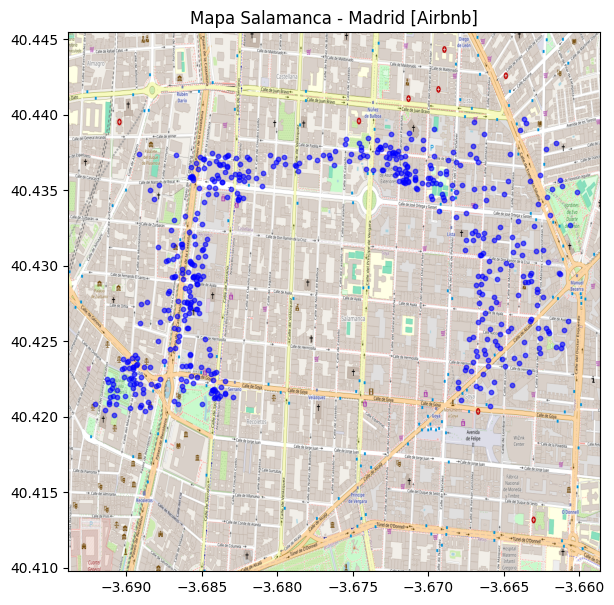

In [94]:
fig, ax = plt.subplots(figsize = (8,7))
ax.scatter(df_salamanca.long, df_salamanca.lat, zorder=1, alpha= 0.6, c='b', s=10)
ax.set_title('Mapa Salamanca - Madrid [Airbnb]')
ax.set_xlim(BBox[0],BBox[1])
ax.set_ylim(BBox[2],BBox[3])
ax.imshow(ruh_m_salamanca, zorder=0, extent = BBox, aspect= 'equal')

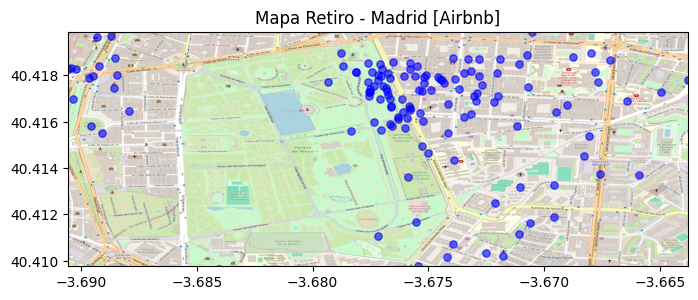

In [95]:
fig, ax = plt.subplots(figsize = (8,7))
ax.scatter(df_retiro.long, df_retiro.lat, zorder=2, alpha= 0.6, c='b', s=28)
ax.set_title('Mapa Retiro - Madrid [Airbnb]')
ax.set_xlim(BBoxR[0],BBoxR[1])
ax.set_ylim(BBoxR[2],BBoxR[3])
ax.imshow(ruh_m_retiro, zorder=0, extent = BBoxR, aspect= 'equal')

---
<span style="color: red" >__Reto:__ el último mapa no está del todo ajustado, te propongo que revises todo el proceso (desde la carga del fichero) y comprueba que tanto la longitud como la latitud son correctas y se corresponden con la zona del mapa. Prueba a descargar un nuevo mapa usando el Zoom de la plataforma.</span>

---

### 6. Agregación Avanzada: Datos de Clientes y Compras

Ahora vamos a trabajar con un conjunto de datos más complejo: información de clientes y sus compras. Estos datos nos permitirán explorar operadores avanzados de agregación como `$lookup`, `$unwind`, operadores de arrays, fechas y expresiones condicionales.

#### 6.1 Carga de datos de clientes y compras

Primero, cargamos dos nuevas colecciones: `clientes` y `compras`. Estos datos tienen una estructura más compleja con documentos anidados y arrays, perfectos para practicar operadores avanzados.

**Nota importante sobre Extended JSON:**

Los archivos JSON exportados desde MongoDB utilizan un formato especial llamado **Extended JSON** para representar tipos de datos específicos de MongoDB:
- `{"$oid": "..."}` para ObjectId
- `{"$date": "..."}` para fechas

Estos no pueden insertarse directamente y deben convertirse a los tipos nativos de PyMongo (ObjectId, datetime, etc.) antes de la inserción.

In [98]:
# Crear las colecciones para clientes y compras
from bson import ObjectId
from datetime import datetime

clientesColl = db.clientes
comprasColl = db.compras

# Función para convertir Extended JSON a formato PyMongo
def convertir_extended_json(doc):
    """Convierte campos en formato Extended JSON a tipos nativos de PyMongo"""
    if isinstance(doc, dict):
        nuevo_doc = {}
        for key, value in doc.items():
            # Convertir ObjectId
            if key == "_id" and isinstance(value, dict) and "$oid" in value:
                nuevo_doc[key] = ObjectId(value["$oid"])
            # Convertir fechas
            elif isinstance(value, dict) and "$date" in value:
                # Puede ser string ISO o timestamp
                date_value = value["$date"]
                if isinstance(date_value, str):
                    nuevo_doc[key] = datetime.fromisoformat(date_value.replace('Z', '+00:00'))
                else:
                    nuevo_doc[key] = datetime.fromtimestamp(date_value / 1000.0)
            # Recursivamente procesar diccionarios y listas
            elif isinstance(value, dict):
                nuevo_doc[key] = convertir_extended_json(value)
            elif isinstance(value, list):
                nuevo_doc[key] = [convertir_extended_json(item) for item in value]
            else:
                nuevo_doc[key] = value
        return nuevo_doc
    elif isinstance(doc, list):
        return [convertir_extended_json(item) for item in doc]
    else:
        return doc

# Cargar datos de clientes
with open("./data/LabTestDB.clientes.json", encoding='utf-8') as f:
    clientes_data = json.load(f)
    
# Cargar datos de compras
with open("./data/LabTestDB.compras.json", encoding='utf-8') as f:
    compras_data = json.load(f)

print(f"Clientes a insertar: {len(clientes_data)}")
print(f"Compras a insertar: {len(compras_data)}")

Clientes a insertar: 200
Compras a insertar: 2061


In [99]:
# Limpiar colecciones si existen
clientesColl.delete_many({})
comprasColl.delete_many({})

# Convertir los datos de Extended JSON a formato PyMongo
clientes_convertidos = [convertir_extended_json(doc) for doc in clientes_data]
compras_convertidas = [convertir_extended_json(doc) for doc in compras_data]

# Insertar los datos
clientesColl.insert_many(clientes_convertidos)
comprasColl.insert_many(compras_convertidas)

print(f"Documentos insertados en clientes: {clientesColl.count_documents({})}")
print(f"Documentos insertados en compras: {comprasColl.count_documents({})}")

Documentos insertados en clientes: 200
Documentos insertados en compras: 2061


#### 6.2 Exploración de la estructura de datos

Vamos a explorar la estructura de los documentos de clientes y compras para entender los campos disponibles.

In [100]:
# Ver un documento de ejemplo de clientes
cliente_ejemplo = clientesColl.find_one({})
print("Estructura de un cliente:")
print(json.dumps(cliente_ejemplo, indent=2, default=str))

Estructura de un cliente:
{
  "_id": "CL0",
  "nombre": "Shalonda Omalley",
  "direccion": {
    "calle": "Calle 62",
    "ciudad": "Monterrey",
    "codigoPostal": "77554"
  },
  "email": "shalonda.omalley@example.com",
  "telefono": "+52-1-357-2039",
  "fecha_registro": "2023-04-30 18:18:17.710000",
  "estatus": "activo",
  "puntos_fidelidad": 729,
  "preferencias": {
    "categorias_favoritas": [
      "libros"
    ],
    "notificaciones": true
  },
  "historial_acceso": [
    {
      "fecha": "2024-03-30 22:07:55.710000",
      "dispositivo": "iPhone"
    },
    {
      "fecha": "2024-04-25 23:02:39.710000",
      "dispositivo": "iPad"
    }
  ],
  "metodos_pago": [
    {
      "tipo": "tarjeta_credito",
      "numero": "**** **** **** 1234",
      "caducidad": "12/24"
    },
    {
      "tipo": "PayPal",
      "correo": "shalonda.omalley@paypal.com"
    }
  ],
  "contacto_emergencia": {
    "nombre": "r",
    "telefono": "+52-1-429-9955",
    "relacion": "familia"
  }
}


In [101]:
# Ver un documento de ejemplo de compras
compra_ejemplo = comprasColl.find_one({})
print("Estructura de una compra:")
print(json.dumps(compra_ejemplo, indent=2, default=str))

Estructura de una compra:
{
  "_id": "663e37dd7867974ab0c03f00",
  "cliente_id": "CL0",
  "fecha": "2024-04-16 16:14:23.724000",
  "total": 293.84,
  "articulos": [
    {
      "producto_id": "584040",
      "nombre": "Smartphone",
      "cantidad": 6,
      "precio_unitario": 67.22
    }
  ],
  "metodo_pago": "tarjeta_credito",
  "estatus": "entregado",
  "direccion_envio": {
    "calle": "Calle 62",
    "ciudad": "Monterrey",
    "codigoPostal": "77554"
  },
  "envio": {
    "tipo": "est\u00e1ndar",
    "costo": 27.74,
    "seguro": false
  },
  "factura": {
    "base_imponible": 278.9,
    "impuestos": 85.23,
    "total_factura": 665.22
  },
  "promociones_aplicadas": [
    {
      "codigo": "DESC10",
      "descuento": 10
    }
  ],
  "comentarios": "Entrega en porter\u00eda",
  "comentarios_producto": "No est\u00e1 mal el servicio brindado. Podr\u00edan mejorar.",
  "registro": [
    {
      "fecha": "2024-05-01 04:36:43.724000",
      "evento": "orden_recibida"
    },
    {
     

#### 6.3 Operador $lookup: Joins entre colecciones

El operador `$lookup` permite realizar operaciones similares a un JOIN en SQL, combinando documentos de diferentes colecciones. Es fundamental cuando necesitas relacionar información de múltiples colecciones.

**Sintaxis básica:**
```python
{
  "$lookup": {
    "from": "coleccion_a_unir",
    "localField": "campo_local",
    "foreignField": "campo_externo",
    "as": "nombre_campo_resultado"
  }
}
```

**Ejemplo 1:** Obtener todas las compras de cada cliente (unir clientes con sus compras)

In [102]:
pipeline = [
    {
        "$lookup": {
            "from": "compras",
            "localField": "_id",
            "foreignField": "cliente_id",
            "as": "compras_realizadas"
        }
    },
    {
        "$project": {
            "_id": 1,
            "nombre": 1,
            "email": 1,
            "total_compras": {"$size": "$compras_realizadas"},
            "compras_realizadas": 1
        }
    },
    {"$limit": 3}
]

resultado = list(clientesColl.aggregate(pipeline))
print(json.dumps(resultado, indent=2, default=str))

[
  {
    "_id": "CL0",
    "nombre": "Shalonda Omalley",
    "email": "shalonda.omalley@example.com",
    "compras_realizadas": [
      {
        "_id": "663e37dd7867974ab0c03f00",
        "cliente_id": "CL0",
        "fecha": "2024-04-16 16:14:23.724000",
        "total": 293.84,
        "articulos": [
          {
            "producto_id": "584040",
            "nombre": "Smartphone",
            "cantidad": 6,
            "precio_unitario": 67.22
          }
        ],
        "metodo_pago": "tarjeta_credito",
        "estatus": "entregado",
        "direccion_envio": {
          "calle": "Calle 62",
          "ciudad": "Monterrey",
          "codigoPostal": "77554"
        },
        "envio": {
          "tipo": "est\u00e1ndar",
          "costo": 27.74,
          "seguro": false
        },
        "factura": {
          "base_imponible": 278.9,
          "impuestos": 85.23,
          "total_factura": 665.22
        },
        "promociones_aplicadas": [
          {
            "co

**Ejemplo 2:** Obtener el total gastado por cada cliente usando $lookup con pipeline

In [103]:
pipeline = [
    {
        "$lookup": {
            "from": "compras",
            "localField": "_id",
            "foreignField": "cliente_id",
            "as": "compras"
        }
    },
    {
        "$addFields": {
            "total_gastado": {"$sum": "$compras.total"},
            "numero_compras": {"$size": "$compras"}
        }
    },
    {
        "$project": {
            "nombre": 1,
            "email": 1,
            "total_gastado": 1,
            "numero_compras": 1,
            "promedio_por_compra": {
                "$cond": {
                    "if": {"$gt": ["$numero_compras", 0]},
                    "then": {"$divide": ["$total_gastado", "$numero_compras"]},
                    "else": 0
                }
            }
        }
    },
    {"$sort": {"total_gastado": -1}},
    {"$limit": 10}
]

resultado = list(clientesColl.aggregate(pipeline))
for cliente in resultado:
    print(f"{cliente['nombre']}: ${cliente['total_gastado']:.2f} en {cliente['numero_compras']} compras (promedio: ${cliente['promedio_por_compra']:.2f})")

Ashley Ybarra: $12587.96 en 19 compras (promedio: $662.52)
Sabrina Tadlock: $12005.14 en 20 compras (promedio: $600.26)
Marsha Thompson: $11698.71 en 20 compras (promedio: $584.94)
Jessie Szymanski: $11690.03 en 20 compras (promedio: $584.50)
Lisa Martin: $11577.93 en 20 compras (promedio: $578.90)
Marilyn Anderson: $11492.48 en 19 compras (promedio: $604.87)
Kattie Mclean: $11410.95 en 19 compras (promedio: $600.58)
Douglas Johnson: $11212.94 en 18 compras (promedio: $622.94)
Sharon Wright: $11175.96 en 19 compras (promedio: $588.21)
Ricardo Perez: $10962.39 en 18 compras (promedio: $609.02)


#### 6.4 Operadores de Array avanzados

MongoDB proporciona operadores potentes para trabajar con arrays: `$filter`, `$map`, `$reduce`, `$arrayElemAt`, `$slice`, etc.

**Ejemplo 1:** Usar `$filter` para obtener solo los artículos con cantidad mayor a 3 en cada compra

In [104]:
pipeline = [
    {
        "$project": {
            "cliente_id": 1,
            "fecha": 1,
            "total": 1,
            "articulos_alta_cantidad": {
                "$filter": {
                    "input": "$articulos",
                    "as": "articulo",
                    "cond": {"$gt": ["$$articulo.cantidad", 3]}
                }
            }
        }
    },
    {
        "$match": {
            "articulos_alta_cantidad": {"$ne": []}
        }
    },
    {"$limit": 5}
]

resultado = list(comprasColl.aggregate(pipeline))
print(json.dumps(resultado, indent=2, default=str))

[
  {
    "_id": "663e37dd7867974ab0c03f00",
    "cliente_id": "CL0",
    "fecha": "2024-04-16 16:14:23.724000",
    "total": 293.84,
    "articulos_alta_cantidad": [
      {
        "producto_id": "584040",
        "nombre": "Smartphone",
        "cantidad": 6,
        "precio_unitario": 67.22
      }
    ]
  },
  {
    "_id": "663e37dd7867974ab0c03f01",
    "cliente_id": "CL0",
    "fecha": "2024-02-23 15:48:35.733000",
    "total": 960.23,
    "articulos_alta_cantidad": [
      {
        "producto_id": "248317",
        "nombre": "Zapatos deportivos",
        "cantidad": 9,
        "precio_unitario": 89.89
      }
    ]
  },
  {
    "_id": "663e37dd7867974ab0c03f02",
    "cliente_id": "CL0",
    "fecha": "2024-04-20 12:53:08.734000",
    "total": 917.6,
    "articulos_alta_cantidad": [
      {
        "producto_id": "356799",
        "nombre": "Mochila",
        "cantidad": 9,
        "precio_unitario": 21.68
      }
    ]
  },
  {
    "_id": "663e37dd7867974ab0c03f03",
    "cliente

**Ejemplo 2:** Usar `$map` para calcular el subtotal de cada artículo (cantidad × precio_unitario)

In [105]:
pipeline = [
    {
        "$project": {
            "cliente_id": 1,
            "total": 1,
            "articulos_con_subtotal": {
                "$map": {
                    "input": "$articulos",
                    "as": "articulo",
                    "in": {
                        "nombre": "$$articulo.nombre",
                        "cantidad": "$$articulo.cantidad",
                        "precio_unitario": "$$articulo.precio_unitario",
                        "subtotal": {
                            "$multiply": ["$$articulo.cantidad", "$$articulo.precio_unitario"]
                        }
                    }
                }
            }
        }
    },
    {"$limit": 3}
]

resultado = list(comprasColl.aggregate(pipeline))
print(json.dumps(resultado, indent=2, default=str))

[
  {
    "_id": "663e37dd7867974ab0c03f00",
    "cliente_id": "CL0",
    "total": 293.84,
    "articulos_con_subtotal": [
      {
        "nombre": "Smartphone",
        "cantidad": 6,
        "precio_unitario": 67.22,
        "subtotal": 403.32
      }
    ]
  },
  {
    "_id": "663e37dd7867974ab0c03f01",
    "cliente_id": "CL0",
    "total": 960.23,
    "articulos_con_subtotal": [
      {
        "nombre": "Zapatos deportivos",
        "cantidad": 9,
        "precio_unitario": 89.89,
        "subtotal": 809.01
      }
    ]
  },
  {
    "_id": "663e37dd7867974ab0c03f02",
    "cliente_id": "CL0",
    "total": 917.6,
    "articulos_con_subtotal": [
      {
        "nombre": "Mochila",
        "cantidad": 9,
        "precio_unitario": 21.68,
        "subtotal": 195.12
      }
    ]
  }
]


#### 6.5 Operadores de Fecha

Los operadores de fecha permiten extraer componentes de fechas, formatear fechas, y realizar cálculos temporales.

**Ejemplo 1:** Agrupar compras por mes y año, calculando el total de ventas por período

In [106]:
pipeline = [
    {
        "$addFields": {
            "fecha_obj": {"$toDate": "$fecha"}
        }
    },
    {
        "$group": {
            "_id": {
                "anio": {"$year": "$fecha_obj"},
                "mes": {"$month": "$fecha_obj"}
            },
            "total_ventas": {"$sum": "$total"},
            "num_compras": {"$sum": 1},
            "promedio_compra": {"$avg": "$total"}
        }
    },
    {
        "$sort": {"_id.anio": 1, "_id.mes": 1}
    },
    {
        "$project": {
            "_id": 0,
            "periodo": {
                "$concat": [
                    {"$toString": "$_id.anio"},
                    "/",
                    {"$toString": "$_id.mes"}
                ]
            },
            "total_ventas": {"$round": ["$total_ventas", 2]},
            "num_compras": 1,
            "promedio_compra": {"$round": ["$promedio_compra", 2]}
        }
    }
]

resultado = list(comprasColl.aggregate(pipeline))
for periodo in resultado:
    print(f"{periodo['periodo']}: ${periodo['total_ventas']:.2f} en {periodo['num_compras']} compras (promedio: ${periodo['promedio_compra']:.2f})")

2024/2: $237898.47 en 434 compras (promedio: $548.15)
2024/3: $391735.96 en 706 compras (promedio: $554.87)
2024/4: $372493.71 en 681 compras (promedio: $546.98)
2024/5: $132050.07 en 240 compras (promedio: $550.21)


**Ejemplo 2:** Analizar ventas por día de la semana

In [107]:
pipeline = [
    {
        "$addFields": {
            "fecha_obj": {"$toDate": "$fecha"}
        }
    },
    {
        "$group": {
            "_id": {"$dayOfWeek": "$fecha_obj"},
            "total_ventas": {"$sum": "$total"},
            "num_compras": {"$sum": 1}
        }
    },
    {
        "$sort": {"_id": 1}
    },
    {
        "$project": {
            "_id": 0,
            "dia_semana": {
                "$switch": {
                    "branches": [
                        {"case": {"$eq": ["$_id", 1]}, "then": "Domingo"},
                        {"case": {"$eq": ["$_id", 2]}, "then": "Lunes"},
                        {"case": {"$eq": ["$_id", 3]}, "then": "Martes"},
                        {"case": {"$eq": ["$_id", 4]}, "then": "Miércoles"},
                        {"case": {"$eq": ["$_id", 5]}, "then": "Jueves"},
                        {"case": {"$eq": ["$_id", 6]}, "then": "Viernes"},
                        {"case": {"$eq": ["$_id", 7]}, "then": "Sábado"}
                    ],
                    "default": "Desconocido"
                }
            },
            "total_ventas": {"$round": ["$total_ventas", 2]},
            "num_compras": 1
        }
    }
]

resultado = list(comprasColl.aggregate(pipeline))
for dia in resultado:
    print(f"{dia['dia_semana']}: ${dia['total_ventas']:.2f} en {dia['num_compras']} compras")

Domingo: $156441.65 en 297 compras
Lunes: $147968.04 en 280 compras
Martes: $176184.27 en 319 compras
Miércoles: $153325.03 en 290 compras
Jueves: $164586.23 en 285 compras
Viernes: $150698.92 en 275 compras
Sábado: $184974.07 en 315 compras


#### 6.6 Operador $bucket: Agrupación por rangos

El operador `$bucket` permite agrupar documentos en rangos o "cubos" basados en valores numéricos. Es útil para crear histogramas o análisis por categorías de precios.

**Ejemplo:** Clasificar compras por rangos de monto total

In [109]:
pipeline = [
    {
        "$bucket": {
            "groupBy": "$total",
            "boundaries": [0, 100, 200, 300, 400, 500],
            "default": "500+",
            "output": {
                "count": {"$sum": 1},
                "compras": {"$push": "$cliente_id"},
                "promedio": {"$avg": "$total"}
            }
        }
    },
    {
        "$project": {
            "rango": {
                "$concat": [
                    {"$toString": "$_id"},
                    " - ",
                    {
                        "$cond": {
                            "if": {"$eq": ["$_id", "500+"]},
                            "then": "∞",
                            "else": {"$toString": {"$add": ["$_id", 99.99]}}
                        }
                    }
                ]
            },
            "cantidad_compras": "$count",
            "monto_promedio": {"$round": ["$promedio", 2]}
        }
    }
]

resultado = list(comprasColl.aggregate(pipeline))
print("Distribución de compras por rango de monto:\n")
for rango in resultado:
    print(f"{rango['rango']}: {rango['cantidad_compras']} compras (promedio: ${rango['monto_promedio']:.2f})")

Distribución de compras por rango de monto:

100 - 199.99: 233 compras (promedio: $149.72)
200 - 299.99: 230 compras (promedio: $249.77)
300 - 399.99: 230 compras (promedio: $347.21)
400 - 499.99: 230 compras (promedio: $451.72)
500+ - ∞: 1138 compras (promedio: $754.04)


#### 6.7 Operador $facet: Agregaciones múltiples simultáneas

El operador `$facet` permite ejecutar múltiples pipelines de agregación en paralelo sobre los mismos documentos. Es extremadamente útil para obtener diferentes perspectivas de los datos en una sola consulta.

**Ejemplo:** Análisis multidimensional de compras: estadísticas generales, top clientes y distribución por estado

In [110]:
pipeline = [
    {
        "$facet": {
            "estadisticas_generales": [
                {
                    "$group": {
                        "_id": None,
                        "total_compras": {"$sum": 1},
                        "monto_total": {"$sum": "$total"},
                        "monto_promedio": {"$avg": "$total"},
                        "monto_max": {"$max": "$total"},
                        "monto_min": {"$min": "$total"}
                    }
                }
            ],
            "top_clientes": [
                {
                    "$group": {
                        "_id": "$cliente_id",
                        "total_gastado": {"$sum": "$total"},
                        "num_compras": {"$sum": 1}
                    }
                },
                {"$sort": {"total_gastado": -1}},
                {"$limit": 5},
                {
                    "$project": {
                        "cliente_id": "$_id",
                        "total_gastado": {"$round": ["$total_gastado", 2]},
                        "num_compras": 1,
                        "_id": 0
                    }
                }
            ],
            "distribucion_por_estado": [
                {
                    "$group": {
                        "_id": "$estatus",
                        "cantidad": {"$sum": 1},
                        "monto_total": {"$sum": "$total"}
                    }
                },
                {"$sort": {"cantidad": -1}}
            ],
            "metodos_pago": [
                {
                    "$group": {
                        "_id": "$metodo_pago",
                        "cantidad": {"$sum": 1},
                        "monto_total": {"$sum": "$total"}
                    }
                },
                {"$sort": {"cantidad": -1}}
            ]
        }
    }
]

resultado = list(comprasColl.aggregate(pipeline))[0]

print("=== ANÁLISIS MULTIDIMENSIONAL DE COMPRAS ===\n")

print("1. ESTADÍSTICAS GENERALES:")
stats = resultado["estadisticas_generales"][0]
print(f"   Total compras: {stats['total_compras']}")
print(f"   Monto total: ${stats['monto_total']:.2f}")
print(f"   Monto promedio: ${stats['monto_promedio']:.2f}")
print(f"   Monto máximo: ${stats['monto_max']:.2f}")
print(f"   Monto mínimo: ${stats['monto_min']:.2f}\n")

print("2. TOP 5 CLIENTES:")
for i, cliente in enumerate(resultado["top_clientes"], 1):
    print(f"   {i}. Cliente {cliente['cliente_id']}: ${cliente['total_gastado']:.2f} ({cliente['num_compras']} compras)")

print("\n3. DISTRIBUCIÓN POR ESTADO:")
for estado in resultado["distribucion_por_estado"]:
    print(f"   {estado['_id']}: {estado['cantidad']} compras (${estado['monto_total']:.2f})")

print("\n4. MÉTODOS DE PAGO:")
for metodo in resultado["metodos_pago"]:
    print(f"   {metodo['_id']}: {metodo['cantidad']} compras (${metodo['monto_total']:.2f})")

=== ANÁLISIS MULTIDIMENSIONAL DE COMPRAS ===

1. ESTADÍSTICAS GENERALES:
   Total compras: 2061
   Monto total: $1134178.21
   Monto promedio: $550.30
   Monto máximo: $998.25
   Monto mínimo: $100.50

2. TOP 5 CLIENTES:
   1. Cliente CL180: $12587.96 (19 compras)
   2. Cliente CL63: $12005.14 (20 compras)
   3. Cliente CL172: $11698.71 (20 compras)
   4. Cliente CL116: $11690.03 (20 compras)
   5. Cliente CL159: $11577.93 (20 compras)

3. DISTRIBUCIÓN POR ESTADO:
   entregado: 2061 compras ($1134178.21)

4. MÉTODOS DE PAGO:
   tarjeta_credito: 2061 compras ($1134178.21)


#### 6.8 Análisis de productos: $unwind con agregación

Ahora vamos a analizar los artículos vendidos. Como los artículos están en un array dentro de cada compra, usaremos `$unwind` para descomponer el array y poder agrupar por producto.

**Ejemplo:** Productos más vendidos con análisis de ingresos

In [111]:
pipeline = [
    {"$unwind": "$articulos"},
    {
        "$group": {
            "_id": "$articulos.nombre",
            "total_unidades": {"$sum": "$articulos.cantidad"},
            "total_ingresos": {
                "$sum": {
                    "$multiply": ["$articulos.cantidad", "$articulos.precio_unitario"]
                }
            },
            "precio_promedio": {"$avg": "$articulos.precio_unitario"},
            "veces_vendido": {"$sum": 1}
        }
    },
    {"$sort": {"total_unidades": -1}},
    {"$limit": 10},
    {
        "$project": {
            "producto": "$_id",
            "total_unidades": 1,
            "total_ingresos": {"$round": ["$total_ingresos", 2]},
            "precio_promedio": {"$round": ["$precio_promedio", 2]},
            "veces_vendido": 1,
            "_id": 0
        }
    }
]

resultado = list(comprasColl.aggregate(pipeline))
print("TOP 10 PRODUCTOS MÁS VENDIDOS:\n")
for i, prod in enumerate(resultado, 1):
    print(f"{i}. {prod['producto']}")
    print(f"   Unidades vendidas: {prod['total_unidades']}")
    print(f"   Ingresos totales: ${prod['total_ingresos']:.2f}")
    print(f"   Precio promedio: ${prod['precio_promedio']:.2f}")
    print(f"   Aparece en {prod['veces_vendido']} compras\n")

TOP 10 PRODUCTOS MÁS VENDIDOS:

1. Libro de cocina
   Unidades vendidas: 1786
   Ingresos totales: $98224.95
   Precio promedio: $55.37
   Aparece en 312 compras

2. Smartphone
   Unidades vendidas: 1721
   Ingresos totales: $95220.44
   Precio promedio: $55.01
   Aparece en 314 compras

3. Zapatos deportivos
   Unidades vendidas: 1710
   Ingresos totales: $96689.92
   Precio promedio: $56.08
   Aparece en 296 compras

4. Reloj inteligente
   Unidades vendidas: 1665
   Ingresos totales: $92266.38
   Precio promedio: $53.93
   Aparece en 298 compras

5. Mochila
   Unidades vendidas: 1638
   Ingresos totales: $88226.33
   Precio promedio: $53.94
   Aparece en 289 compras

6. Laptop
   Unidades vendidas: 1575
   Ingresos totales: $83568.69
   Precio promedio: $53.98
   Aparece en 289 compras

7. Cámara
   Unidades vendidas: 1495
   Ingresos totales: $82389.35
   Precio promedio: $54.54
   Aparece en 263 compras



#### 6.9 Pipeline complejo: Análisis de clientes con segmentación

Vamos a crear un pipeline complejo que combine múltiples operadores para segmentar clientes según su comportamiento de compra.

In [112]:
pipeline = [
    {
        "$lookup": {
            "from": "compras",
            "localField": "_id",
            "foreignField": "cliente_id",
            "as": "compras"
        }
    },
    {
        "$addFields": {
            "total_gastado": {"$sum": "$compras.total"},
            "num_compras": {"$size": "$compras"},
            "ultima_compra": {"$max": "$compras.fecha"}
        }
    },
    {
        "$match": {
            "num_compras": {"$gt": 0}
        }
    },
    {
        "$addFields": {
            "promedio_compra": {
                "$cond": {
                    "if": {"$gt": ["$num_compras", 0]},
                    "then": {"$divide": ["$total_gastado", "$num_compras"]},
                    "else": 0
                }
            },
            "segmento": {
                "$switch": {
                    "branches": [
                        {
                            "case": {
                                "$and": [
                                    {"$gte": ["$total_gastado", 1000]},
                                    {"$gte": ["$num_compras", 5]}
                                ]
                            },
                            "then": "VIP"
                        },
                        {
                            "case": {
                                "$and": [
                                    {"$gte": ["$total_gastado", 500]},
                                    {"$gte": ["$num_compras", 3]}
                                ]
                            },
                            "then": "Premium"
                        },
                        {
                            "case": {"$gte": ["$num_compras", 2]},
                            "then": "Recurrente"
                        }
                    ],
                    "default": "Nuevo"
                }
            }
        }
    },
    {
        "$group": {
            "_id": "$segmento",
            "cantidad_clientes": {"$sum": 1},
            "gasto_total": {"$sum": "$total_gastado"},
            "gasto_promedio": {"$avg": "$total_gastado"},
            "compras_promedio": {"$avg": "$num_compras"}
        }
    },
    {
        "$sort": {"gasto_total": -1}
    },
    {
        "$project": {
            "segmento": "$_id",
            "cantidad_clientes": 1,
            "gasto_total": {"$round": ["$gasto_total", 2]},
            "gasto_promedio": {"$round": ["$gasto_promedio", 2]},
            "compras_promedio": {"$round": ["$compras_promedio", 2]},
            "_id": 0
        }
    }
]

resultado = list(clientesColl.aggregate(pipeline))
print("=== SEGMENTACIÓN DE CLIENTES ===\n")
for segmento in resultado:
    print(f"Segmento: {segmento['segmento']}")
    print(f"  Clientes: {segmento['cantidad_clientes']}")
    print(f"  Gasto total: ${segmento['gasto_total']:.2f}")
    print(f"  Gasto promedio por cliente: ${segmento['gasto_promedio']:.2f}")
    print(f"  Compras promedio por cliente: {segmento['compras_promedio']:.2f}\n")

=== SEGMENTACIÓN DE CLIENTES ===

Segmento: VIP
  Clientes: 159
  Gasto total: $1082105.57
  Gasto promedio por cliente: $6805.70
  Compras promedio por cliente: 12.40

Segmento: Premium
  Clientes: 13
  Gasto total: $23941.56
  Gasto promedio por cliente: $1841.66
  Compras promedio por cliente: 3.31

Segmento: Recurrente
  Clientes: 18
  Gasto total: $21474.71
  Gasto promedio por cliente: $1193.04
  Compras promedio por cliente: 2.00

Segmento: Nuevo
  Clientes: 10
  Gasto total: $6656.37
  Gasto promedio por cliente: $665.64
  Compras promedio por cliente: 1.00



#### 6.10 Operador $sortByCount: Frecuencias ordenadas

El operador `$sortByCount` es un atajo conveniente para agrupar por un campo y contar ocurrencias, ordenando automáticamente por frecuencia descendente.

**Ejemplo 1:** Ciudades con más clientes

In [113]:
pipeline = [
    {"$sortByCount": "$direccion.ciudad"}
]

resultado = list(clientesColl.aggregate(pipeline))
print("Clientes por ciudad:\n")
for ciudad in resultado[:10]:
    print(f"{ciudad['_id']}: {ciudad['count']} clientes")

Clientes por ciudad:

Puebla: 48 clientes
Monterrey: 44 clientes
Querétaro: 43 clientes
Ciudad de México: 34 clientes
Guadalajara: 31 clientes


**Ejemplo 2:** Categorías favoritas más populares (usando $unwind)

In [114]:
pipeline = [
    {"$unwind": "$preferencias.categorias_favoritas"},
    {"$sortByCount": "$preferencias.categorias_favoritas"}
]

resultado = list(clientesColl.aggregate(pipeline))
print("Categorías favoritas más populares:\n")
for cat in resultado:
    print(f"{cat['_id']}: {cat['count']} clientes")

Categorías favoritas más populares:

electrónicos: 136 clientes
libros: 132 clientes
ropa: 127 clientes


### 7. Ejercicios Prácticos

Ahora es tu turno. Intenta resolver los siguientes ejercicios usando los datos de clientes y compras:

**Ejercicio 1:** Encuentra los 5 clientes con más puntos de fidelidad y muestra su nombre, puntos, y ciudad.

In [ ]:
# Tu código aquí
pipeline = [
    # Completa el pipeline
]

# resultado = list(clientesColl.aggregate(pipeline))

**Ejercicio 2:** Calcula el monto total de compras por ciudad de envío. Ordena el resultado de mayor a menor.

In [ ]:
# Tu código aquí
pipeline = [
    # Completa el pipeline
]

# resultado = list(comprasColl.aggregate(pipeline))

**Ejercicio 3:** Encuentra todas las compras que incluyen promociones aplicadas. Usa `$filter` para obtener solo las compras con descuentos mayores al 15%.

In [ ]:
# Tu código aquí
pipeline = [
    # Completa el pipeline
]

# resultado = list(comprasColl.aggregate(pipeline))

**Ejercicio 4:** Crea un pipeline complejo que combine `$lookup`, `$unwind`, y `$group` para encontrar qué cliente ha comprado más unidades de un producto específico. Muestra el nombre del cliente, el producto y la cantidad total.

In [ ]:
# Tu código aquí
pipeline = [
    # Completa el pipeline
]

# resultado = list(comprasColl.aggregate(pipeline))

### 8. Conclusiones y Recursos Adicionales

En este cuaderno hemos explorado el framework de agregación de MongoDB desde Python usando PyMongo. Hemos cubierto:

**Operadores básicos:**
* `$match`: Filtrar documentos
* `$project`: Seleccionar campos específicos
* `$group`: Agrupar y calcular agregados
* `$sort`: Ordenar resultados
* `$limit`: Limitar número de resultados

**Operadores avanzados:**
* `$lookup`: Realizar joins entre colecciones
* `$unwind`: Descomponer arrays
* `$addFields`: Agregar campos calculados
* `$bucket`: Agrupar por rangos
* `$facet`: Múltiples agregaciones simultáneas
* `$sortByCount`: Contar y ordenar por frecuencia

**Operadores especializados:**
* **Arrays**: `$filter`, `$map`, `$size`, `$arrayElemAt`
* **Fechas**: `$year`, `$month`, `$dayOfWeek`, `$dateToString`
* **Condicionales**: `$cond`, `$switch`
* **Matemáticos**: `$add`, `$multiply`, `$divide`, `$round`
* **String**: `$concat`, `$toString`

**Recursos adicionales:**
* [MongoDB Aggregation Pipeline](https://docs.mongodb.com/manual/core/aggregation-pipeline/)
* [PyMongo Documentation](https://pymongo.readthedocs.io/)
* [Aggregation Operators Reference](https://docs.mongodb.com/manual/reference/operator/aggregation/)